# 02. EDA and preprocessing

This notebook explores the IBM transaction data and sets up the preprocessing pipeline in src/preprocessing.py. A few points matter for later. The data has no naturally missing values. Amount Paid is very heavily skewed, around 219, so it is log-transformed. Account IDs are almost unique and are dropped. The data is split by day, with days 1 to 3 used as the clean reference and days 4 to 10 as the incoming stream. All of this runs on the full file rather than a head sample.

In [4]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd
from preprocessing import load_transactions, temporal_split, build_module1_features
from injection import inject_anomalies
DATA_PATH = '../data/HI-Small_Trans.csv'   # <--HPC path

In [5]:
df = load_transactions(DATA_PATH)
print('shape:', df.shape)
print('skew:', round(df['Amount Paid'].skew(),1))
print('natural missing:', int(df.isna().sum().sum()))
print('laundering rate: %.4f%%' % (100*df['Is Laundering'].mean()))

shape: (5078345, 11)
skew: 858.7
natural missing: 0
laundering rate: 0.1019%


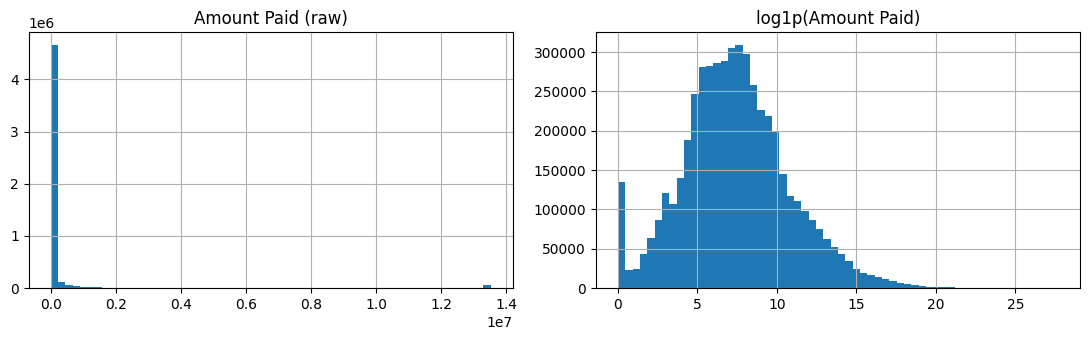

In [6]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
df['Amount Paid'].clip(upper=df['Amount Paid'].quantile(0.99)).hist(bins=60,ax=ax[0]); ax[0].set_title('Amount Paid (raw)')
np.log1p(df['Amount Paid']).hist(bins=60,ax=ax[1]); ax[1].set_title('log1p(Amount Paid)')
plt.tight_layout(); plt.savefig('../results/amount_distribution.png',dpi=120); plt.show()

## Temporal split + features (fit on reference, apply to incoming)

In [7]:
ref, inc = temporal_split(df, reference_days=3, max_days=10)
print(f'reference: {ref.shape[0]:,}  {ref.Timestamp.min()} -> {ref.Timestamp.max()}')
print(f'incoming : {inc.shape[0]:,}  {inc.Timestamp.min()} -> {inc.Timestamp.max()}')
Xref, scaler, names = build_module1_features(ref, fit=True)
print('features:', names, '| std ~1:', np.round(Xref.std(0),2))

reference: 2,076,752  2022-09-01 00:00:00 -> 2022-09-03 23:59:00
incoming : 3,000,485  2022-09-04 00:00:00 -> 2022-09-10 23:59:00
features: ['log_amount', 'hour', 'dayofweek', 'day'] | std ~1: [1. 1. 1. 1.]


In [8]:
inc_c, gt = inject_anomalies(inc, 'Amount Paid', rate=0.02, multiplier=50, seed=42)
Xinc,_,_ = build_module1_features(inc_c, scaler=scaler, fit=False)
la=Xinc[:,0]; a=gt.values
print(f'scaled log_amount clean={la[~a].mean():.2f} anomaly={la[a].mean():.2f} sep={la[a].mean()-la[~a].mean():.2f}')

scaled log_amount clean=-0.07 anomaly=0.99 sep=1.06
